Random Forest ( 100 Decision Tree with 20 depth ) Result

In [1]:
#Environment Setup & Library Imports

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
import warnings
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text


In [3]:
#Read UNSW Datasets
UNSW_Train_Data=pd.DataFrame(pd.read_csv("UNSW_Training.csv"))
UNSW_test_data=pd.DataFrame(pd.read_csv("UNSW_test_File.csv"))

#Combine UNSW Dataset
DataFrames = [UNSW_test_data,UNSW_Train_Data]
Combine_Datasets = pd.concat(DataFrames)
Combine_Datasets.to_csv("Combine_UNSW_Dataset.csv", index=None, header=True)


#Read Combined UNSW dataset
UNSW_train = pd.read_csv('Combine_UNSW_Dataset.csv')


In [4]:
# Handling Missing Values
X = UNSW_train[['dur','proto','service','state','spkts','dpkts','sbytes','dbytes','rate','sttl','dttl','sload','dload','sloss','dloss','sinpkt','dinpkt','sjit','djit','swin','stcpb','dtcpb','dwin','tcprtt','synack','ackdat','smean','dmean','trans_depth','response_body_len','ct_srv_src','ct_state_ttl','ct_dst_ltm','ct_src_dport_ltm','ct_dst_sport_ltm','ct_dst_src_ltm','is_ftp_login','ct_ftp_cmd','ct_flw_http_mthd','ct_src_ltm','ct_srv_dst','is_sm_ips_ports']]
y = UNSW_train['attack_cat']

print("Missing values per column:")
print((X.isnull().sum().sum())+(y.isnull().sum().sum()))

print("\n[Handling Values]")
X.replace([np.inf, -np.inf], np.nan, inplace=True)
y.replace([np.inf, -np.inf], np.nan, inplace=True)
inf_count = (X.isnull().sum().sum())+(y.isnull().sum().sum())
if inf_count > 0:
    print(f"Found {inf_count} infinite/null values")
    X.fillna(0, inplace=True)
    y.fillna("Normal", inplace=True)

# encoded Y Value
y_encoded=y.map({'Normal': 0, 'Backdoor': 1,'DoS' :2,'Exploits':3,'Fuzzers':4,'Generic':5,'Reconnaissance':6,'Shellcode':7,'Worms':8,'Analysis':9})


#Split UNSW dataset into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.35, random_state=42)
print(f"\\n🔀 Train/Test Split:")
print(f"   Training samples : {X_train.shape[0]:,}")
print(f"   Testing samples  : {X_test.shape[0]:,}")



Missing values per column:
0

[Handling Values]
\n🔀 Train/Test Split:
   Training samples : 167,487
   Testing samples  : 90,186


/tmp/ipykernel_23391/2798122273.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.replace([np.inf, -np.inf], np.nan, inplace=True)


In [5]:
#Initialize RandomForest Model Classifier with 100 Decision Tree
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42,max_depth=8)

#Train the Model
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)

# Display the classification report
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred )
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)
print("\n========== Classification Report Description ==========")
print(f"0 : Normal")
print(f"1 : Backdoor")
print(f"2 : DoS")
print(f"3 : Exploits")
print(f"4 : Fuzzers")
print(f"5 : Generic")
print(f"6 : Reconnaissance")
print(f"7 : Shellcode")
print(f"8 : Worms")
print(f"9 : Analysis")
print("========================================================")


Accuracy: 0.81

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.94      0.91     32543
           1       1.00      0.00      0.00       824
           2       0.77      0.01      0.01      5793
           3       0.57      0.95      0.71     15539
           4       0.71      0.46      0.56      8538
           5       1.00      0.97      0.99     20487
           6       0.84      0.66      0.74      4956
           7       0.00      0.00      0.00       527
           8       0.00      0.00      0.00        62
           9       1.00      0.01      0.02       917

    accuracy                           0.81     90186
   macro avg       0.68      0.40      0.39     90186
weighted avg       0.83      0.81      0.77     90186


========== Classification Report Description ==========
0 : Normal
1 : Backdoor
2 : DoS
3 : Exploits
4 : Fuzzers
5 : Generic
6 : Reconnaissance
7 : Shellcode
8 : Worms
9 : Analysis


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


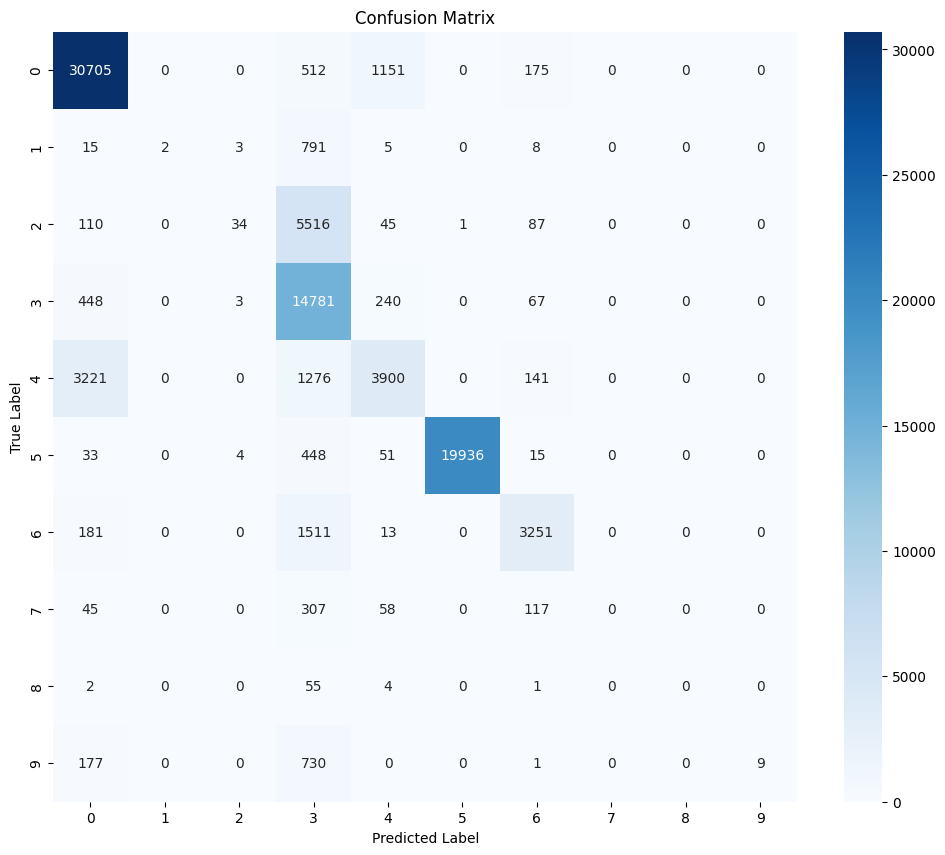


==========  Description ==========
0 : Normal
1 : Backdoor
2 : DoS
3 : Exploits
4 : Fuzzers
5 : Generic
6 : Reconnaissance
7 : Shellcode
8 : Worms
9 : Analysis


In [6]:
# Visualize the confusion matrix

plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\n==========  Description ==========")
print(f"0 : Normal")
print(f"1 : Backdoor")
print(f"2 : DoS")
print(f"3 : Exploits")
print(f"4 : Fuzzers")
print(f"5 : Generic")
print(f"6 : Reconnaissance")
print(f"7 : Shellcode")
print(f"8 : Worms")
print(f"9 : Analysis")
print("========================================================")

Decision Tree - 8 Depth (Random Forest)


Missing values per column:
0

[Handling Values]


/tmp/ipykernel_23391/2514079859.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.replace([np.inf, -np.inf], np.nan, inplace=True)


\n🔀 Train/Test Split:
   Training samples : 167,487
   Testing samples  : 90,186
|--- ct_dst_sport_ltm <= 3.50
|   |--- sttl <= 61.00
|   |   |--- sinpkt <= 0.00
|   |   |   |--- smean <= 58.00
|   |   |   |   |--- class: Normal
|   |   |   |--- smean >  58.00
|   |   |   |   |--- state <= 1.50
|   |   |   |   |   |--- sbytes <= 62.50
|   |   |   |   |   |   |--- dur <= 0.00
|   |   |   |   |   |   |   |--- class: DoS
|   |   |   |   |   |   |--- dur >  0.00
|   |   |   |   |   |   |   |--- class: DoS
|   |   |   |   |   |--- sbytes >  62.50
|   |   |   |   |   |   |--- class: Normal
|   |   |   |   |--- state >  1.50
|   |   |   |   |   |--- ct_srv_src <= 3.50
|   |   |   |   |   |   |--- ct_srv_dst <= 2.50
|   |   |   |   |   |   |   |--- ct_dst_sport_ltm <= 1.50
|   |   |   |   |   |   |   |   |--- class: Exploits
|   |   |   |   |   |   |   |--- ct_dst_sport_ltm >  1.50
|   |   |   |   |   |   |   |   |--- class: Exploits
|   |   |   |   |   |   |--- ct_srv_dst >  2.50
|   |   |   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.79

Classification Report:
                 precision    recall  f1-score   support

      Analysis       0.79      0.03      0.05       917
      Backdoor       0.25      0.00      0.00       824
           DoS       0.51      0.05      0.09      5793
      Exploits       0.55      0.91      0.69     15539
       Fuzzers       0.59      0.33      0.42      8538
       Generic       1.00      0.97      0.99     20487
        Normal       0.86      0.94      0.90     32543
Reconnaissance       0.92      0.62      0.74      4956
     Shellcode       0.90      0.02      0.03       527
         Worms       0.00      0.00      0.00        62

      accuracy                           0.79     90186
     macro avg       0.64      0.39      0.39     90186
  weighted avg       0.79      0.79      0.75     90186



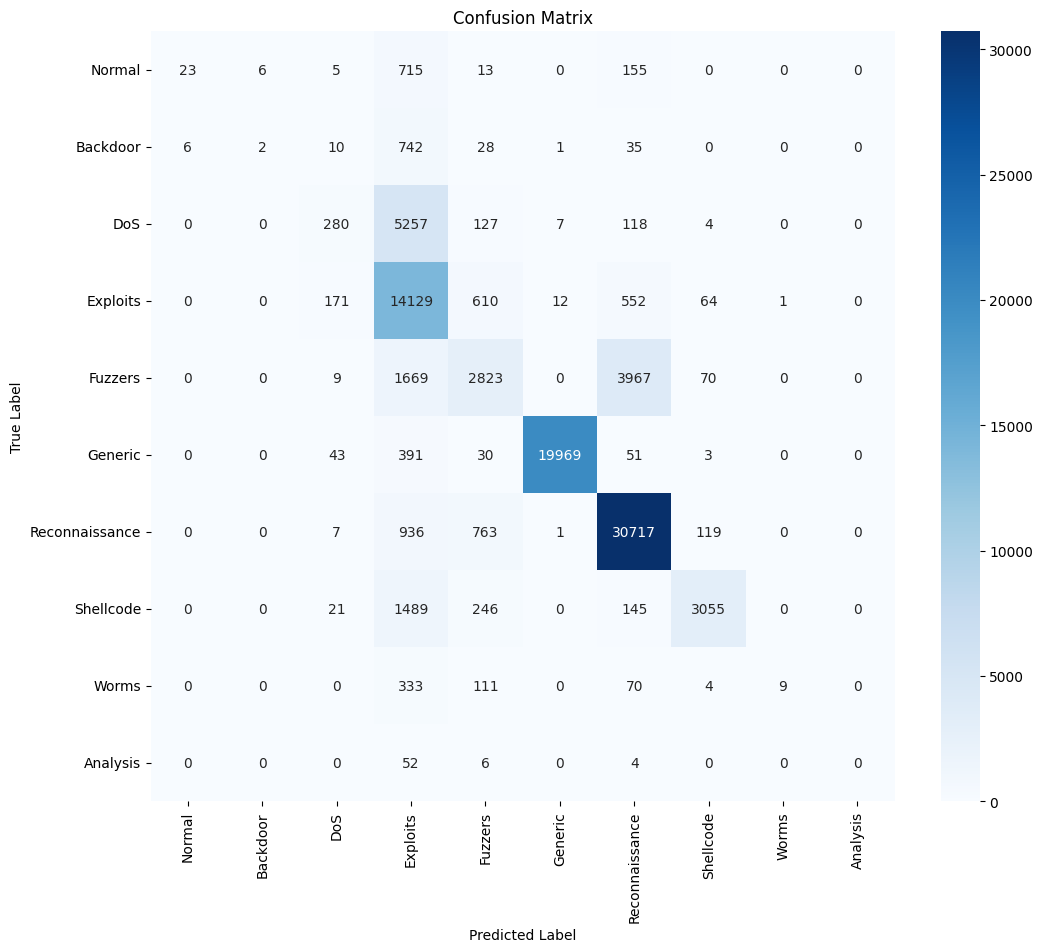

In [7]:

UNSW_Train_Data=pd.DataFrame(pd.read_csv("UNSW_Training.csv"))
UNSW_test_data=pd.DataFrame(pd.read_csv("UNSW_test_File.csv"))

#Combine UNSW Dataset
DataFrames = [UNSW_test_data,UNSW_Train_Data]
Combine_Datasets = pd.concat(DataFrames)
Combine_Datasets.to_csv("Combine_UNSW_Dataset.csv", index=None, header=True)


  #Read Combined UNSW dataset
UNSW_train = pd.read_csv('Combine_UNSW_Dataset.csv')

X = UNSW_train[['dur','proto','service','state','spkts','dpkts','sbytes','dbytes','rate','sttl','dttl','sload','dload','sloss','dloss','sinpkt','dinpkt','sjit','djit','swin','stcpb','dtcpb','dwin','tcprtt','synack','ackdat','smean','dmean','trans_depth','response_body_len','ct_srv_src','ct_state_ttl','ct_dst_ltm','ct_src_dport_ltm','ct_dst_sport_ltm','ct_dst_src_ltm','is_ftp_login','ct_ftp_cmd','ct_flw_http_mthd','ct_src_ltm','ct_srv_dst','is_sm_ips_ports']]
y = UNSW_train['attack_cat']

print("Missing values per column:")
print((X.isnull().sum().sum())+(y.isnull().sum().sum()))

print("\n[Handling Values]")
X.replace([np.inf, -np.inf], np.nan, inplace=True)
y.replace([np.inf, -np.inf], np.nan, inplace=True)
inf_count = (X.isnull().sum().sum())+(y.isnull().sum().sum())
if inf_count > 0:
    print(f"Found {inf_count} infinite/null values")
    X.fillna(0, inplace=True)
    y.fillna("Normal", inplace=True)



x_train,x_test,y_train,y_test = train_test_split (X,y, test_size = 0.35,random_state=42,)
decision_tree = DecisionTreeClassifier( random_state=15,max_depth=8)
decision_tree = decision_tree.fit(x_train,y_train)
print(f"\\n🔀 Train/Test Split:")
print(f"   Training samples : {x_train.shape[0]:,}")
print(f"   Testing samples  : {x_test.shape[0]:,}")
Decision_Tree_1_Report = export_text(decision_tree,feature_names=['dur','proto','service','state','spkts','dpkts','sbytes','dbytes','rate','sttl','dttl','sload','dload','sloss','dloss','sinpkt','dinpkt','sjit','djit','swin','stcpb','dtcpb','dwin','tcprtt','synack','ackdat','smean','dmean','trans_depth','response_body_len','ct_srv_src','ct_state_ttl','ct_dst_ltm','ct_src_dport_ltm','ct_dst_sport_ltm','ct_dst_src_ltm','is_ftp_login','ct_ftp_cmd','ct_flw_http_mthd','ct_src_ltm','ct_srv_dst','is_sm_ips_ports'])
print(Decision_Tree_1_Report)


y_pred = decision_tree.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)


# Visualize the confusion matrix
labels=["Normal","Backdoor","DoS","Exploits","Fuzzers","Generic","Reconnaissance","Shellcode","Worms","Analysis"]

plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_test, y_pred ,labels=["Analysis","Backdoor","DoS","Exploits","Fuzzers","Generic","Normal","Reconnaissance","Shellcode","Worms"]), annot=True, fmt='d',
            cmap='Blues',xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()





Random Forest ( 3 Decision Tree - 8 depth) Result

In [9]:

# Handling Missing Values
X = UNSW_train[['dur','proto','service','state','spkts','dpkts','sbytes','dbytes','rate','sttl','dttl','sload','dload','sloss','dloss','sinpkt','dinpkt','sjit','djit','swin','stcpb','dtcpb','dwin','tcprtt','synack','ackdat','smean','dmean','trans_depth','response_body_len','ct_srv_src','ct_state_ttl','ct_dst_ltm','ct_src_dport_ltm','ct_dst_sport_ltm','ct_dst_src_ltm','is_ftp_login','ct_ftp_cmd','ct_flw_http_mthd','ct_src_ltm','ct_srv_dst','is_sm_ips_ports']]
y = UNSW_train['attack_cat']

print("Missing values per column:")
print((X.isnull().sum().sum())+(y.isnull().sum().sum()))

print("\n[Handling Values]")
X.replace([np.inf, -np.inf], np.nan, inplace=True)
y.replace([np.inf, -np.inf], np.nan, inplace=True)
inf_count = (X.isnull().sum().sum())+(y.isnull().sum().sum())
if inf_count > 0:
    print(f"Found {inf_count} infinite/null values")
    X.fillna(0, inplace=True)
    y.fillna("Normal", inplace=True)

# encoded Y Value
y_encoded=y.map({'Normal': 0, 'Backdoor': 1,'DoS' :2,'Exploits':3,'Fuzzers':4,'Generic':5,'Reconnaissance':6,'Shellcode':7,'Worms':8,'Analysis':9})


#Split UNSW dataset into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.35, random_state=42)
print(f"\\n🔀 Train/Test Split:")
print(f"   Training samples : {X_train.shape[0]:,}")
print(f"   Testing samples  : {X_test.shape[0]:,}")


#Initialize RandomForest Model Classifier with 100 Decision Tree
rf_classifier = RandomForestClassifier(n_estimators=1, random_state=42,max_depth=8)

#Train the Model
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)

# Display the classification report
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred )
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:\n", classification_rep)
print("\n========== Classification Report Description ==========")
print(f"0 : Normal")
print(f"1 : Backdoor")
print(f"2 : DoS")
print(f"3 : Exploits")
print(f"4 : Fuzzers")
print(f"5 : Generic")
print(f"6 : Reconnaissance")
print(f"7 : Shellcode")
print(f"8 : Worms")
print(f"9 : Analysis")



Missing values per column:
0

[Handling Values]
\n🔀 Train/Test Split:
   Training samples : 167,487
   Testing samples  : 90,186


/tmp/ipykernel_23391/1572974455.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.replace([np.inf, -np.inf], np.nan, inplace=True)


Accuracy: 0.79

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.90      0.89     32543
           1       0.00      0.00      0.00       824
           2       0.37      0.01      0.02      5793
           3       0.57      0.91      0.70     15539
           4       0.58      0.51      0.54      8538
           5       1.00      0.97      0.99     20487
           6       0.69      0.63      0.66      4956
           7       0.55      0.03      0.06       527
           8       0.18      0.03      0.05        62
           9       0.33      0.00      0.00       917

    accuracy                           0.79     90186
   macro avg       0.51      0.40      0.39     90186
weighted avg       0.77      0.79      0.76     90186


========== Classification Report Description ==========
0 : Normal
1 : Backdoor
2 : DoS
3 : Exploits
4 : Fuzzers
5 : Generic
6 : Reconnaissance
7 : Shellcode
8 : Worms
9 : Analysis


Random Forest Test Result

In [34]:
sample = X_test.iloc[0:5]
prediction = rf_classifier.predict(sample)

sample_dict = sample.iloc[1].to_dict()


print(f"\nSample Traffics: {sample_dict }")
if (prediction[1] == 5 ):
  print(f"\nPrediction: Normal")
if (prediction[1] == 1 ):
  print(f"\nPrediction: Backdoor")
if (prediction[1] == 2 ):
  print (f"\nPrediction: DoS")
if (prediction[1] == 3 ):
  print(f"\nPrediction: Exploits")
if (prediction[1] == 4 ):
  print(f"\nPrediction: Fuzzers")
if (prediction[1] == 5 ):
  print(f"\nPrediction: Generic")
if (prediction[1] == 6 ):
  print(f"\nPrediction: Reconnaissance")
if (prediction[1] == 7 ):
  print(f"\nPrediction: Shellcode")
if (prediction[1] == 8 ):
  print(f"\nPrediction: Worms")
if (prediction[1] == 9 ):
  print(f"\nPrediction: Analysis")




Sample Traffics: {'dur': 8e-06, 'proto': 79.0, 'service': 0.0, 'state': 3.0, 'spkts': 2.0, 'dpkts': 0.0, 'sbytes': 200.0, 'dbytes': 0.0, 'rate': 125000.0003, 'sttl': 254.0, 'dttl': 0.0, 'sload': 100000000.0, 'dload': 0.0, 'sloss': 0.0, 'dloss': 0.0, 'sinpkt': 0.008, 'dinpkt': 0.0, 'sjit': 0.0, 'djit': 0.0, 'swin': 0.0, 'stcpb': 0.0, 'dtcpb': 0.0, 'dwin': 0.0, 'tcprtt': 0.0, 'synack': 0.0, 'ackdat': 0.0, 'smean': 100.0, 'dmean': 0.0, 'trans_depth': 0.0, 'response_body_len': 0.0, 'ct_srv_src': 6.0, 'ct_state_ttl': 2.0, 'ct_dst_ltm': 1.0, 'ct_src_dport_ltm': 1.0, 'ct_dst_sport_ltm': 1.0, 'ct_dst_src_ltm': 6.0, 'is_ftp_login': 0.0, 'ct_ftp_cmd': 0.0, 'ct_flw_http_mthd': 0.0, 'ct_src_ltm': 8.0, 'ct_srv_dst': 6.0, 'is_sm_ips_ports': 0.0}

Prediction: Exploits
